In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pickle


In [7]:
import os
os.getcwd()

'C:\\Users\\Madhura\\Desktop\\Climate-Change-Modeling\\notebooks'

In [8]:
import os
os.listdir("..")

['data', 'model', 'notebooks', 'visuals']

In [9]:
os.listdir("../data")

['climate_data.csv.zip']

In [12]:
df = pd.read_csv("../data/climate_data.csv.zip")
df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


In [25]:
df.tail()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,Year
8599207,2013-05-01,11.464,0.236,Zwolle,Netherlands,52.24N,5.26E,2013
8599208,2013-06-01,15.043,0.261,Zwolle,Netherlands,52.24N,5.26E,2013
8599209,2013-07-01,18.775,0.193,Zwolle,Netherlands,52.24N,5.26E,2013
8599210,2013-08-01,18.025,0.298,Zwolle,Netherlands,52.24N,5.26E,2013
8599211,2013-09-01,NaN,NaN,Zwolle,Netherlands,52.24N,5.26E,2013


In [13]:
df['dt'] = pd.to_datetime(df['dt'])
df['Year'] = df['dt'].dt.year

In [14]:
df = df[['Year', 'LandAverageTemperature']]
df.head()

KeyError: "['LandAverageTemperature'] not in index"

In [15]:
df.columns

Index(['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'City',
       'Country', 'Latitude', 'Longitude', 'Year'],
      dtype='object')

In [16]:
df.columns = df.columns.str.strip()

In [17]:
df['dt'] = pd.to_datetime(df['dt'])
df['Year'] = df['dt'].dt.year

In [18]:
df_india = df[df['Country'] == 'India']

In [19]:
df_india = df_india.dropna()

In [20]:
df_india = df_india.groupby('Year')['AverageTemperature'].mean().reset_index()
df_india.head()

,Year,AverageTemperature
0,1796,25.444699
1,1797,26.594590
2,1798,25.054708
3,1799,25.723100
4,1800,25.693772


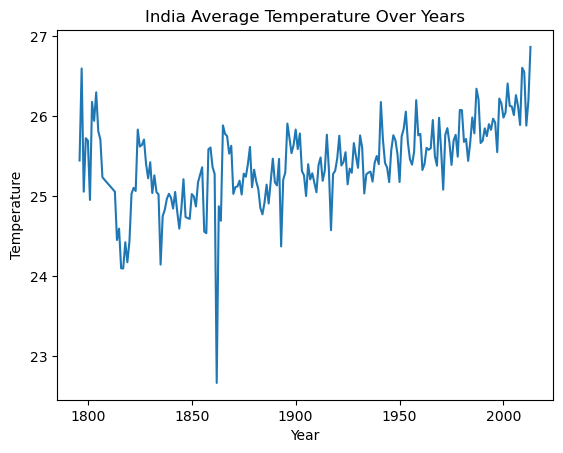

In [21]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_india['Year'], df_india['AverageTemperature'])
plt.title("India Average Temperature Over Years")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df_india[['Year']]
y = df_india['AverageTemperature']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [23]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.6569401000299997


In [24]:
model.predict([[2030]])
model.predict([[2040]])
model.predict([[2050]])

C:\Users\Madhura\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\Madhura\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\Madhura\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([26.63598734])

In [26]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

from sklearn.metrics import r2_score

print("Linear Regression R2:", r2_score(y_test, lr_pred))
print("Random Forest R2:", r2_score(y_test, y_pred))

Linear Regression R2: 0.4486297186310444
Random Forest R2: 0.6569401000299997


In [27]:
df_india['Decade'] = (df_india['Year'] // 10) * 10

decade_avg = df_india.groupby('Decade')['AverageTemperature'].mean()
print(decade_avg)

Decade
1790    25.704274
1800    25.726683
1810    24.412330
1820    25.304821
1830    24.950421
1840    24.850648
1850    25.096910
1860    25.143583
1870    25.211600
1880    25.084887
1890    25.344843
1900    25.383284
1910    25.267784
1920    25.452289
1930    25.371536
1940    25.577359
1950    25.685308
1960    25.608778
1970    25.635102
1980    25.855157
1990    25.882834
2000    26.157131
2010    26.371447
Name: AverageTemperature, dtype: float64


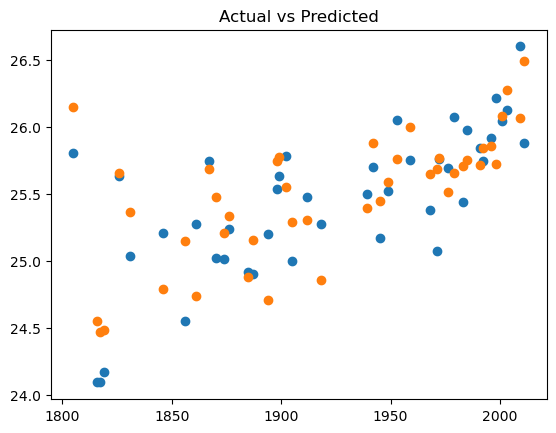

In [30]:
plt.figure()
plt.scatter(X_test, y_test)
plt.scatter(X_test, y_pred)
plt.title("Actual vs Predicted")
plt.show()

In [31]:
with open("../model/random_forest_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [34]:
plt.figure(figsize=(8,5))
plt.plot(df_india['Year'], df_india['AverageTemperature'])
plt.title("India Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Average Temperature")
plt.tight_layout()
plt.savefig("../visuals/temperature_trend.png")
plt.close()